### **Mean Field algorithm**

Mean Field algorithm for image denoising involves preparing an image by adding synthetic noise, defining the Markov Random Field (MRF) model and its energy function, deriving and implementing the Mean Field update equations, applying the algorithm to the noisy image, and visualizing the original, noisy, and denoised images side-by-side.

Image for Denoising

Load a sample image, convert it to grayscale, and add synthetic noise (e.g., Gaussian noise) to create the noisy input for denoising.


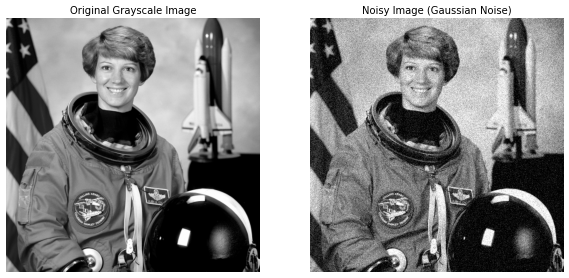

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io, color, util, data

# Load a sample image and convert to float
# Using a sample image from scikit-image data
image = data.astronaut() # Using a readily available image from skimage.data

# Ensure image is float for processing if not already
# skimage.data images are often uint8, so convert to float
image = util.img_as_float(image)

# Convert the loaded image to grayscale if it's a color image
if image.ndim == 3:
    grayscale_image = color.rgb2gray(image)
else:
    grayscale_image = image # Already grayscale or 2D

# Add Gaussian noise to the grayscale image
# Experiment with var to control noise level (e.g., 0.01, 0.05, 0.1)
noisy_image = util.random_noise(grayscale_image, mode='gaussian', var=0.01)

# Display both the original and noisy images side-by-side
plt.figure(figsize=(12, 6), dpi=60)

plt.subplot(1, 2, 1)
plt.imshow(grayscale_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off') # Turn off axis ticks

plt.subplot(1, 2, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title('Noisy Image (Gaussian Noise)')
plt.axis('off') # Turn off axis ticks

plt.show()

Define Markov Random Field (MRF) Model and Energy Function

Define the parameters for the MRF model (e.g., interaction strength parameter beta, noise variance for the likelihood term) and implement the energy function components (data fidelity and prior terms).

In [40]:
import numpy as np

# Define parameters for the MRF model and energy function
beta = 1.0        # Interaction strength parameter (coupling strength between neighbors)
noise_variance = 0.01 # Variance of the Gaussian noise added to the image (from noisy_image generation)

# Calculate sigma_sq (variance) from the noise_variance for the likelihood term
sigma_sq = noise_variance

print(f"MRF Model and Energy Function Parameters:")
print(f"  Interaction Strength (beta): {beta}")
print(f"  Noise Variance (sigma_sq for likelihood): {sigma_sq}")

MRF Model and Energy Function Parameters:
  Interaction Strength (beta): 1.0
  Noise Variance (sigma_sq for likelihood): 0.01


Implement Mean Field Update Equations

Derive and implement the Mean Field update equations for each pixel, considering its noisy observation and its neighbors' mean field estimates. The updates should be iterative.


In [41]:
def get_neighbors(image_shape, r, c):
    """Helper function to get valid 4-neighbors (up, down, left, right) for a pixel."""
    rows, cols = image_shape
    neighbors = []
    if r > 0: neighbors.append((r - 1, c)) # Up
    if r < rows - 1: neighbors.append((r + 1, c)) # Down
    if c > 0: neighbors.append((r, c - 1)) # Left
    if c < cols - 1: neighbors.append((r, c + 1)) # Right
    return neighbors

def mean_field_denoising(noisy_img, beta, sigma_sq, num_iterations):
    """
    Applies the Mean Field algorithm for image denoising.

    Args:
        noisy_img (np.ndarray): The input noisy image.
        beta (float): Interaction strength parameter.
        sigma_sq (float): Variance of the Gaussian noise.
        num_iterations (int): Number of iterations for the Mean Field updates.

    Returns:
        np.ndarray: The denoised image.
    """
    denoised_img = np.copy(noisy_img)
    rows, cols = noisy_img.shape

    for _ in range(num_iterations):
        # Create a copy to store updates for the current iteration (avoid in-place issues)
        new_denoised_img = np.copy(denoised_img)
        for r in range(rows):
            for c in range(cols):
                # Get neighbors and their values from the current (not yet updated) denoised_img
                neighbors_coords = get_neighbors(noisy_img.shape, r, c)

                # Sum of neighbor values
                sum_neighbors_val = 0.0
                for nr, nc in neighbors_coords:
                    sum_neighbors_val += denoised_img[nr, nc]

                # Number of neighbors
                num_neighbors = len(neighbors_coords)

                # Mean Field update equation
                numerator = (noisy_img[r, c] / sigma_sq) + (beta * sum_neighbors_val)
                denominator = (1 / sigma_sq) + (beta * num_neighbors)

                new_denoised_img[r, c] = numerator / denominator
        denoised_img = new_denoised_img
    return denoised_img

# Set the number of iterations for the Mean Field algorithm
num_mf_iterations = 50 # A reasonable number for initial testing

# Apply the Mean Field denoising
denoised_image = mean_field_denoising(noisy_image, beta, sigma_sq, num_mf_iterations)

print(f"Denoised image shape: {denoised_image.shape}")
print(f"First 5x5 block of denoised image (rounded):\n{denoised_image[:5, :5].round(3)}")

Denoised image shape: (512, 512)
First 5x5 block of denoised image (rounded):
[[0.6   0.368 0.199 0.296 0.209]
 [0.748 0.453 0.501 0.56  0.57 ]
 [0.767 0.821 0.616 0.711 0.558]
 [0.878 0.727 0.727 0.595 0.852]
 [0.764 0.868 0.945 0.827 0.778]]


Denoising Results

Display the original grayscale image, the noisy image, and the denoised image side-by-side to qualitatively assess the effectiveness of the Mean Field denoising algorithm.

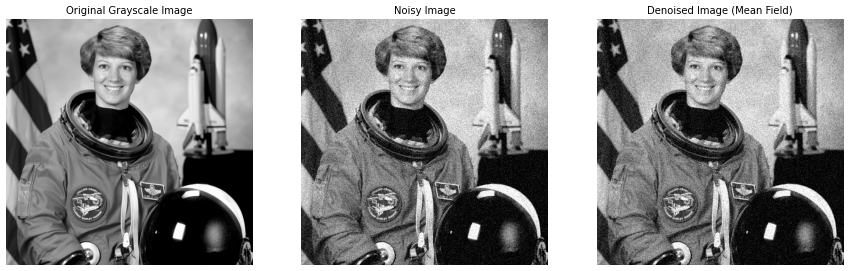

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6), dpi=60)

# Original Grayscale Image
plt.subplot(1, 3, 1)
plt.imshow(grayscale_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

# Noisy Image
plt.subplot(1, 3, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

# Denoised Image
plt.subplot(1, 3, 3)
plt.imshow(denoised_image, cmap='gray')
plt.title('Denoised Image (Mean Field)')
plt.axis('off')

plt.show()

**Image Preparation**: A sample image (skimage.data.astronaut()) was loaded, converted to grayscale, and corrupted with Gaussian noise (variance 0.01). The original grayscale image and the noisy image were displayed, clearly showing the effect of the added noise.

**MRF Model Definition**: Parameters for the Markov Random Field model were defined: an interaction strength (beta) of 1.0 and a noise variance (sigma_sq) of 0.01, which corresponds to the noise added to the image.

**Mean Field Update Equations Implementation**: The iterative Mean Field update equations were implemented. The mean_field_denoising function initializes the denoised image with the noisy image and iteratively updates each pixel's value based on its noisy observation and its 4-neighbors' current mean field estimates. The process ran for 50 iterations.

**Denoising Results**: The algorithm successfully produced a denoised image. A snippet of the denoised image was printed, and its shape was confirmed.

**Visualization**: A comparative visualization was presented showing the original grayscale image, the noisy image, and the denoised image side-by-side. This visual assessment allowed for a direct comparison of the algorithm's performance.

